# Module 7 — Multimodal Models

## Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in Colab*

### Setup Notebook Environment

### Installing Python Libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
import pkg_resources
try:
    import google.colab
    IN_COLAB = True
    print("Running on Colab, let's run through the installs")
except ImportError:
    IN_COLAB = False
    print("Running locally, assuming you have a venv setup already done.")

def check_and_get_missing(requirements):
    to_install = []
    for pkg, ver in requirements.items():
        try:
            installed = pkg_resources.get_distribution(pkg).version
            if ver and installed != ver:
                print(f"Version mismatch for {pkg}: found {installed}, need {ver}")
                to_install.append(f"{pkg}=={ver}")
        except pkg_resources.DistributionNotFound:
            print(f"Package {pkg} not found.")
            to_install.append(f"{pkg}=={ver}" if ver else pkg)
    return to_install

if IN_COLAB:
    # 1. PYTORCH CHECK
    torch_reqs = {"torch": "2.2.0", "torchvision": "0.17.0", "torchaudio": "2.2.0"}
    missing_torch = check_and_get_missing(torch_reqs)
    if missing_torch:
        print("Uninstalling potentially conflicting torch packages...")
        !pip uninstall -y torch torchvision torchaudio
        print("Installing correct PyTorch versions...")
        !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

    # 2. CORE LIBRARIES CHECK
    core_reqs = {
        "chromadb": "0.5.5",
        "numpy": "1.26.4",
        "transformers": "5.5.4",
        "posthog": "2.5.0",
        "ollama": None
    }
    missing_core = check_and_get_missing(core_reqs)
    if missing_core:
        print(f"Installing/Updating: {missing_core}")
        !pip install -U {' '.join(missing_core)}

    # 3. UNSLOTH CHECK
    try:
        import unsloth
    except ImportError:
        print("Installing Unsloth...")
        !pip install --no-cache-dir unsloth

    import torch
    print("Final Check - Torch:", torch.__version__, "CUDA:", torch.version.cuda)

/tmp/ipykernel_5545/1512986679.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Running on Colab, let's run through the installs
Version mismatch for torch: found 2.2.0+cu121, need 2.2.0
Version mismatch for torchvision: found 0.17.0+cu121, need 0.17.0
Version mismatch for torchaudio: found 2.2.0+cu121, need 2.2.0
Uninstalling potentially conflicting torch packages...
Found existing installation: torch 2.2.0+cu121
Uninstalling torch-2.2.0+cu121:
  Successfully uninstalled torch-2.2.0+cu121
Found existing installation: torchvision 0.17.0+cu121
Uninstalling torchvision-0.17.0+cu121:
  Successfully uninstalled torchvision-0.17.0+cu121
Found existing installation: torchaudio 2.2.0+cu121
Uninstalling torchaudio-2.2.0+cu121:
  Successfully uninstalled torchaudio-2.2.0+cu121
Installing correct PyTorch versions...
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.2.0%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.17.0%2Bcu121-cp

Get Ollama (this is what we are using to interact with the model and manage it)

In [2]:
import subprocess
import os
import glob

def _is_already_installed(service_name: str) -> bool:
    result = subprocess.run(['which', service_name], capture_output=True)
    if result.returncode == 0:
        print(service_name, " already installed")
        return True
    return False

def find_course_dir_gdrive() -> str:
    matches = [
        os.path.dirname(m)
        for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True)
        if 'applied-ml-course' in open(m).read()
    ]
    if not matches:
        return input("Please enter the correct path to 'student_scaffolding' folder in your Google Drive: ")
    return matches[0]


if IN_COLAB:
    !sudo apt-get install zstd
    if not _is_already_installed("ollama"):
        # Install Ollama
        !curl -fsSL https://ollama.com/install.sh | sh


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (14.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently 

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

[Documentation](https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5)

Options:
  - Choose Classic Token
  - Give access to repo

In [3]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/watspeed/language-models.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")


    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: fix/technical-issues-review)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['CLAUDE.md', 'README.md', '.git', 'src', 'notebook_image_catalogue.md', 'uv.lock', 'notebooks', 'upload_to_colab.sh', '.claude', 'pyproject.toml', '.gitignore', 'technical_issues.md', 'prompts', 'course_setup.md', 'data', 'project_structure.md', '.python-version']


In [4]:
from IPython.display import display, Markdown

### Start Ollama and Load the Model

In [5]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b
!ollama pull gemma4:e4b
!ollama pull nomic-embed-text

In [6]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

"Hello! 👋  It's nice to hear from you. 😊 \n\nI am Gemma, an AI assistant here to help you with any questions or tasks you might have. How can I assist you today? \n"

---

## What Multimodality Means

A unimodal model processes one type of input: text in, text out. A multimodal model accepts inputs from more than one modality — images, audio, sensor readings — and reasons across them jointly.

The key architectural insight: **transformers don't care what the tokens represent** — words, image patches, audio frames, sensor readings — as long as you can express each as a fixed-size vector. Multimodality is the art of building those vectors consistently enough that a single transformer can attend across all of them.

## What Kinds of Modalities Exist

| Modality | Encoding approach | Example models |
|---|---|---|
| **Vision (images)** | 16×16 px patches → ViT encoder → token embeddings | Gemma 4, LLaVA, CLIP |
| **Video** | Same as vision but per-frame, with temporal position encoding | Video-LLaMA, MERLOT |
| **Audio** | Waveform → mel spectrogram (a 2D image) → patch encoding | Whisper, VATT |
| **Documents/charts** | High-res image tiled into sub-images to preserve text legibility | Gemma 4, PaliGemma |
| **Sensors/scientific data** | Any signal representable as a sequence of vectors | SEMI (arxiv 2509.04606) |

The pattern is always the same: **modality-specific encoder → projection into a shared token space → language model attends across everything**.

Audio is a useful example of how this generalises: a raw waveform is converted into a mel spectrogram — a 2D time × frequency grid, which is just an image. The same patch encoder that reads a recipe card can read audio. This is why the transformer architecture extends so naturally to new modalities: once you can express any input as a token sequence, the model's core machinery doesn't change.

## What Data Is Needed to Train a Multimodal Model

Three training stages, three types of data:

| Stage | Goal | Data required |
|---|---|---|
| **1. Vision encoder pre-training** | Teach the encoder to represent visual structure | Millions of images — either labeled (ImageNet-style) or self-supervised patch-prediction pairs |
| **2. Vision-language alignment** | Pull image and text embeddings into the same space | Hundreds of millions of image-caption pairs (web alt-text, stock photo descriptions) with contrastive loss (CLIP-style) |
| **3. Multimodal instruction fine-tuning** | Teach the model to generate grounded language responses | Image + question + answer triples, document QA datasets, chart/OCR tasks, visual instruction following |

**The quality of Stage 3 data determines the model's specialization.** A model fine-tuned on natural photos struggles with structured documents; one fine-tuned on document QA and OCR tasks (like Gemma 4, via its PaliGemma lineage) excels at reading recipe cards, invoices, and charts.

Adding a new modality — satellite imagery, molecular structures, time-series sensor data — used to require retraining from scratch. Recent work ([SEMI, arxiv 2509.04606](https://arxiv.org/abs/2509.04606)) shows that by sharing a projector hypernetwork across modalities, you can adapt to a new modality with 64× less paired data, borrowing alignment knowledge from modalities the model already understands.

## Image Based MultiModal

A multimodal model has two paths that converge before the transformer:

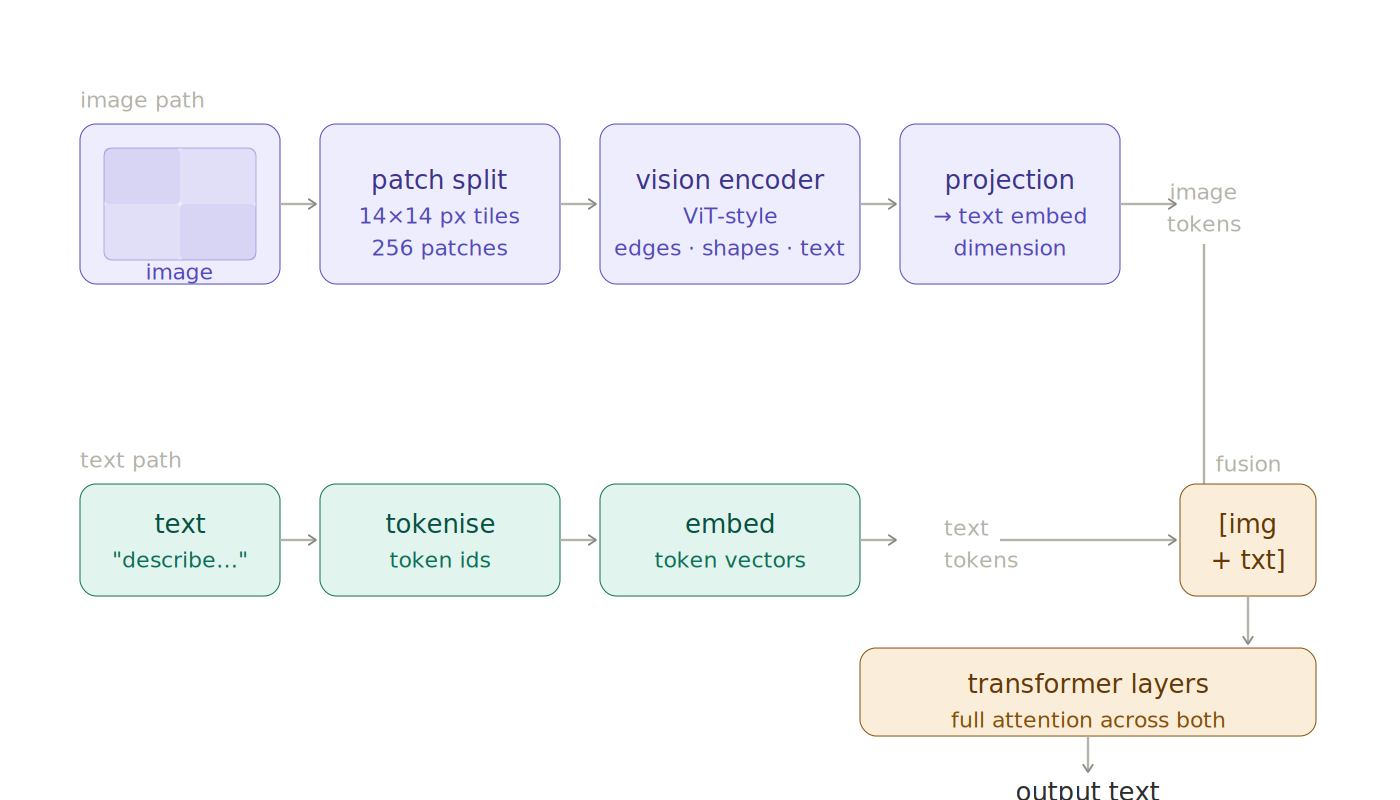


1. **Patch splitting** — the image is divided into fixed-size tiles (e.g. 16×16 pixels each). A 224×224 image becomes 196 patches (14 patches per side).
2. **Vision encoder** — each patch is embedded and passed through a transformer (ViT-style). The encoder learns what visual patterns matter: edges, textures, shapes, text on a page.
3. **Projection** — the encoder output is linearly projected to the same dimensionality as text token embeddings.
4. **Fusion** — the projected image tokens are prepended to the text token sequence. The language model attends across both as if they were one sequence.

**The key insight:** in this architecture, the base language model weights are frozen. It receives tokens — some of which happen to encode visual patches rather than words. Everything it learned about language, reasoning, and structured output still applies.

## Fusion: How Image and Text Meet

There are two common strategies for combining image tokens and text tokens:

**Early fusion (what Gemma 4 uses):**
Image tokens are prepended to the text token sequence before entering the transformer. The model attends across image and text jointly from layer one. Simple, fast, and works well when the vision encoder and language model are jointly trained.

**Cross-attention fusion:**
Text tokens attend to the vision encoder's output via a separate cross-attention mechanism. The two streams stay separate for longer before merging. More architectural complexity but gives the model finer control over how visual information influences each layer.


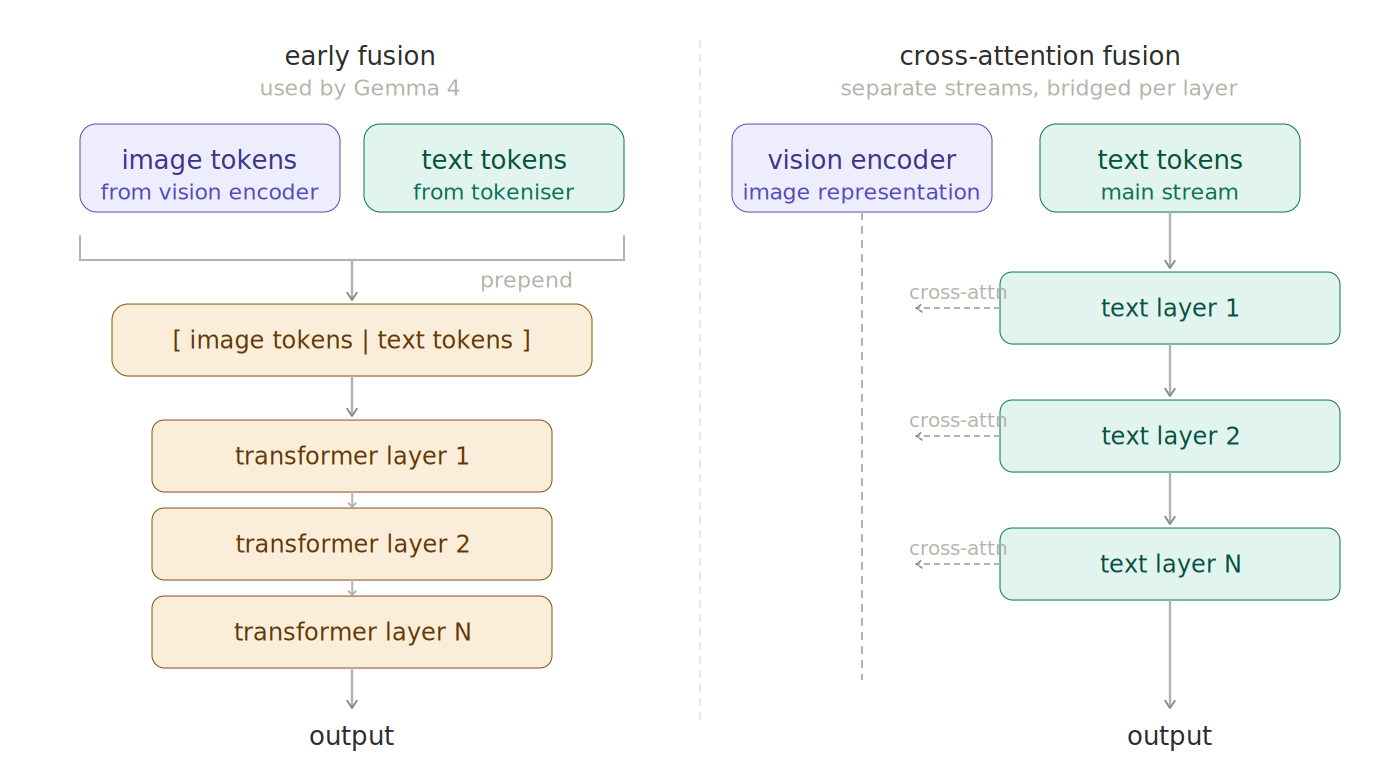

For this week we're using Gemma 4 (`gemma4:e4b`) — early fusion, jointly trained on documents, charts, natural images, and code screenshots. Particularly strong at document understanding, which makes it well-suited to reading recipe cards.

The document strength comes from its PaliGemma lineage: unlike models trained mainly on natural photos, it was fine-tuned on structured document tasks (OCR, chart understanding, visual QA) — which is why it reliably reads recipe-card text rather than hallucinating ingredients. The full architectural breakdown (SigLIP encoder, image tiling, the `e4b` variant) is in Part 3.

Check out this visual guide for gemma architecture for a deeper understanding into the topic [newsletter.maartengrootendorst.com](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-gemma-4)

## Resources

If you want to go deeper:

- **ViT** — the original patch-embedding paper: ["An Image is Worth 16×16 Words"](https://arxiv.org/abs/2010.11929) (Dosovitskiy et al., 2020)
- **CLIP** — contrastive image-text pre-training that connected vision and language in a shared space: [openai.com/research/clip](https://openai.com/research/clip)
- **LLaVA** — the open-source model that popularized the vision projector + frozen LLM approach: [llava-vl.github.io](https://llava-vl.github.io/)
- [**Gemma 4 Architecture a visual representation**](https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-gemma-4)

---
## Extending Our Recipes Problem with Photos

We have two sample cookbook photos in `data/sample_recipes/` — a Taco Bake (straightforward) and a Pasta Carbonara (technique-heavy). The goal: We are going to extend our pipeline to allow users to provide a picture and extract a recipe from it.

### Extract Recipe from Image

Pass the cookbook photo to `gemma4:e4b` with a structured extraction prompt. The model reads the image and returns JSON with three fields: `recipe_name`, `ingredients`, `directions`.

**The choices being made — and what students can change for their own domain:**

- **Vision model = `gemma4:e4b`.** Picked for document understanding (reading recipe-card text and preserving structure). For natural-photo extraction (e.g. identifying objects in a scene) you might prefer a generalist model like `llava` or `qwen2.5-vl`. The Ollama model registry lists available vision models — the contract used here (image + text prompt → text response) is the same across them, so swapping is a one-line change.
- **Prompt structure.** The prompt is a single user message that says *"return JSON only, here are the required fields."* Two levers: the field list (drop ones you don't need, add ones you do — `prep_time`, `serves`, `tags`); and the strictness phrasing (`"no markdown fences"` reduces the rate of malformed output, but doesn't eliminate it — that's what the next section handles).
- **`temperature=0`.** Determinism for an extraction task: same image should give the same output every time. For a creative task (e.g. captioning) you'd raise this; for extraction, leave it at zero.
- **Single image per call.** Some vision models accept multiple images and reason across them — useful for "compare these two photos" tasks. For your own domain: if you have multi-page documents, you'll either tile/concat into one image or run one call per page and merge the results downstream.

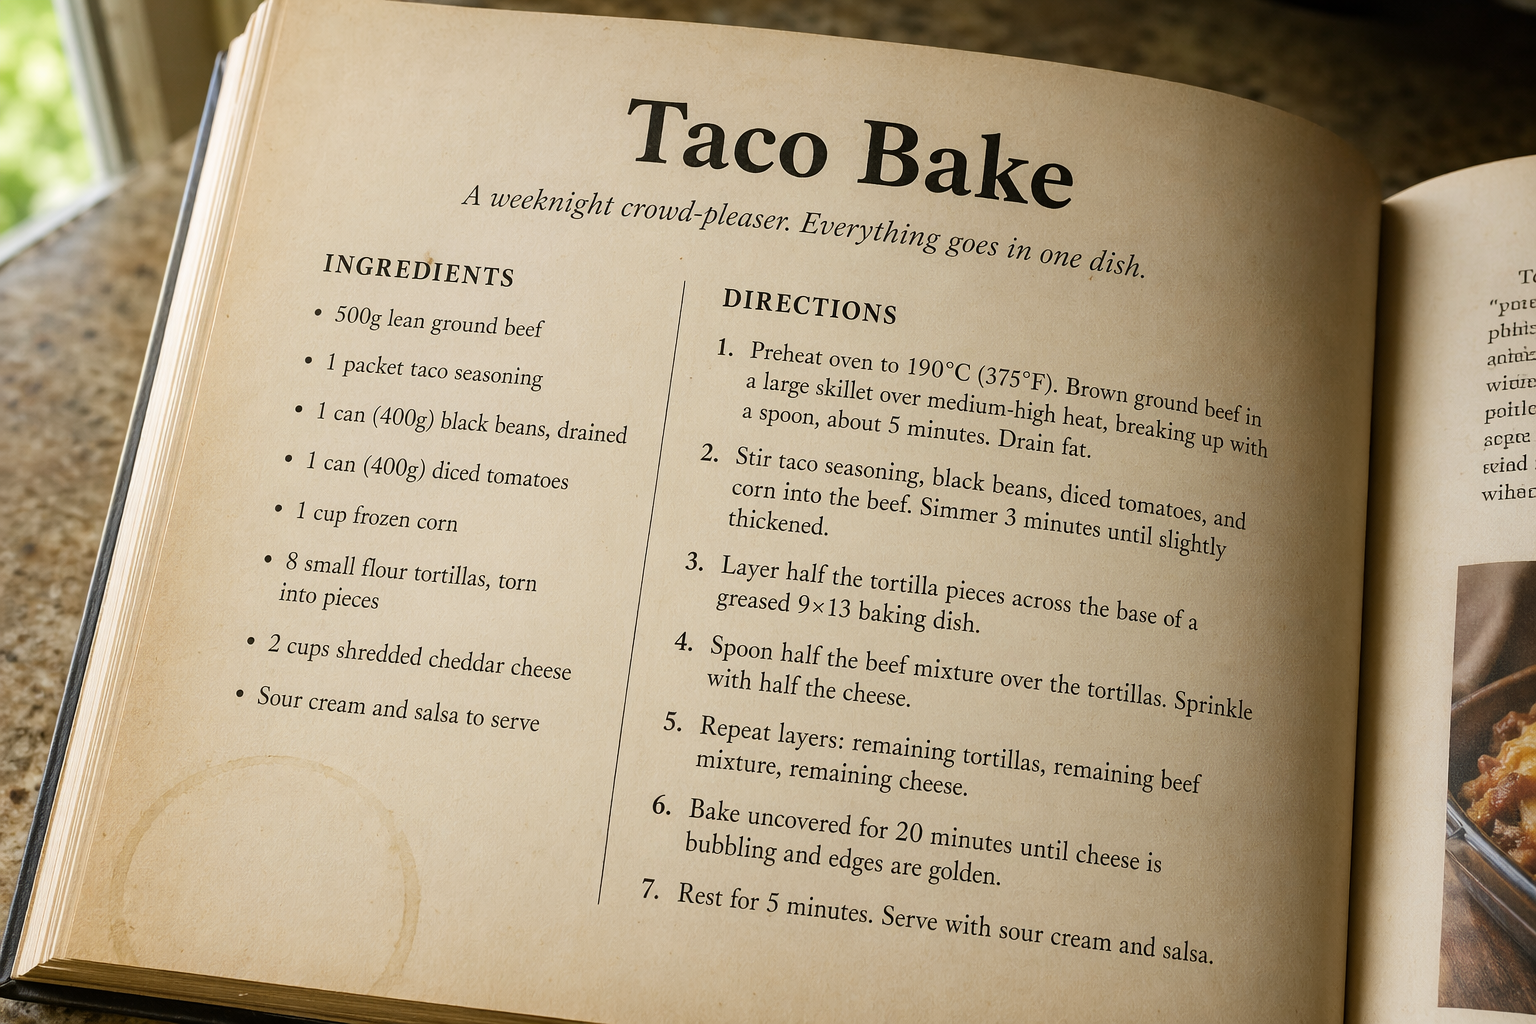

Extracting recipe from image...

Raw model output:
{"recipe_name": "Taco Bake", "ingredients": ["500g lean ground beef", "1 packet taco seasoning", "1 can (400g) black beans, drained", "1 can (400g) diced tomatoes", "1 cup frozen corn", "8 small flour tortillas, torn into pieces", "2 cups shredded cheddar cheese", "Sour cream and salsa to serve"], "directions": ["Preheat oven to 350°F (175°C). Brown ground beef in a large skillet over medium-high heat, breaking up with a spoon, about 5 minutes. Drain fat.", "Stir taco seasoning, black beans, diced tomatoes, and corn into the beef. Simmer 3 minutes until slightly thickened.", "Layer half the tortilla pieces across the base of a grease 9x13 baking dish.", "Spoon half the beef mixture over the tortillas. Sprinkle with half the cheese.", "Repeat layers: remaining tortillas, remaining beef mixture, remaining cheese.", "Bake uncovered for 20 minutes until cheese is bubbling and edges are golden.", "Rest for 5 minutes. Serve with sour cream a

In [9]:
import base64
import json
import ollama
from pathlib import Path
from IPython.display import display, Image as IPImage

VISION_MODEL  = "gemma4:e4b"   # multimodal — reads images
TEXT_MODEL    = "gemma2:2b"    # text-only — used for correction and classification

EXTRACTION_PROMPT = """Extract the recipe from this cookbook image.
Return JSON only — no explanation, no markdown fences.
Required fields:
  recipe_name: string
  ingredients: list of strings (one item per bullet)
  directions: list of strings (one string per numbered step)"""


def load_image_b64(image_path: str) -> str:
    """Load an image file and return as base64 string for Ollama."""
    return base64.b64encode(Path(image_path).read_bytes()).decode()


def extract_recipe_raw(image_path: str) -> str:
    """Call gemma4:e4b with the image and return the raw text response."""
    response = ollama.chat(
        model=VISION_MODEL,
        messages=[{
            "role":    "user",
            "content": EXTRACTION_PROMPT,
            "images":  [load_image_b64(image_path)],
        }],
        options={"temperature": 0},
    )
    return response.message.content.strip()


# Demo: Taco Bake (straightforward recipe)
TACO_IMAGE      = "data/sample_recipes/taco_bake_recipe_card.png"
CARBONARA_IMAGE = "data/sample_recipes/carbonara_recipe_card.png"
display(IPImage(TACO_IMAGE, width=500))

print("Extracting recipe from image...")
raw_output = extract_recipe_raw(TACO_IMAGE)
print("\nRaw model output:")
print(raw_output[:1200])

---
### Handling Malformed Output

Vision models don't always return perfect JSON. The model might wrap the output in markdown fences, add an explanation, or return a subtly malformed structure. In production, a single failed parse shouldn't crash the pipeline.

This cell shows two things:
1. What malformed output looks like in practice
2. A two-step recovery: strip common formatting issues, then use `gemma2:2b` as a corrector if the parse still fails

The corrector model only sees text — it reformats the extraction output to match the schema. It never sees the image. This is a real production pattern: a cheap, fast text model cleaning up after a more capable but less predictable vision model.

In [10]:
import re
from typing import Optional

EXPECTED_SCHEMA = """{
  "recipe_name": "string",
  "ingredients": ["string", "string", "..."],
  "directions":  ["string", "string", "..."]
}"""


def strip_markdown_fences(text: str) -> str:
    """Remove ```json ... ``` or ``` ... ``` wrappers if present."""
    text = re.sub(r'^```(?:json)?\s*', '', text.strip(), flags=re.MULTILINE)
    text = re.sub(r'```\s*$', '', text.strip(), flags=re.MULTILINE)
    return text.strip()


def correct_with_model(malformed_text: str) -> str:
    """Ask gemma2:2b to reformat malformed extraction output to match the schema.

    The corrector never sees the image — it only does schema repair on text.
    Cheap, fast, and keeps the vision model's semantic content intact.
    """
    response = ollama.chat(
        model=TEXT_MODEL,
        messages=[{
            "role":    "user",
            "content": (
                f"The following text should be valid JSON matching this schema:\n{EXPECTED_SCHEMA}\n\n"
                f"Reformat it to match exactly. Return JSON only — no explanation.\n\n"
                f"Text to reformat:\n{malformed_text}"
            ),
        }],
        options={"temperature": 0},
    )
    return response.message.content.strip()


def parse_extraction(raw_text: str, max_retries: int = 1) -> Optional[dict]:
    """Parse raw model output to dict. Attempt correction if parsing fails.

    Step 1: strip markdown fences (most common failure mode)
    Step 2: if still invalid, ask corrector model to reformat
    Step 3: if still invalid after retries, return None and surface raw text
    """
    # Step 1: strip formatting
    cleaned = strip_markdown_fences(raw_text)
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    # Step 2: corrector model
    for attempt in range(max_retries):
        print(f"  JSON parse failed — asking corrector model (attempt {attempt + 1})...")
        corrected = strip_markdown_fences(correct_with_model(cleaned))
        try:
            return json.loads(corrected)
        except json.JSONDecodeError:
            cleaned = corrected  # feed corrected output into next attempt

    # Step 3: give up gracefully
    print("  Could not parse after correction. Raw output returned for inspection:")
    print(raw_text[:400])
    return None


# Show the failure mode explicitly — a fabricated malformed output
MALFORMED_EXAMPLE = """
```json
Sure! Here's the extracted recipe:
{
  "recipe_name": "Taco Bake",
  "ingredients": "500g lean ground beef, 1 packet taco seasoning, 1 can black beans",
  "directions": "1. Preheat oven. 2. Brown beef. 3. Layer and bake."
}
```
"""

print("=== Demonstrating the failure mode ===")
print("Malformed output (ingredients and directions are strings, not lists):")
print(MALFORMED_EXAMPLE)

print("\nStep 1 — strip markdown fences:")
step1 = strip_markdown_fences(MALFORMED_EXAMPLE)
print(step1[:200])

try:
    json.loads(step1)
    print("Parse succeeded after stripping.")
except json.JSONDecodeError as e:
    print(f"Still invalid JSON: {e}")
    print()
    print("Step 2 — corrector model (gemma2:2b reformats to schema):")
    result = parse_extraction(MALFORMED_EXAMPLE)
    if result:
        print("Corrected successfully:")
        print(f"  recipe_name: {result['recipe_name']}")
        print(f"  ingredients: {len(result['ingredients'])} items (type: {type(result['ingredients']).__name__})")
        print(f"  directions:  {len(result['directions'])} steps (type: {type(result['directions']).__name__})")

=== Demonstrating the failure mode ===
Malformed output (ingredients and directions are strings, not lists):

```json
Sure! Here's the extracted recipe:
{
  "recipe_name": "Taco Bake",
  "ingredients": "500g lean ground beef, 1 packet taco seasoning, 1 can black beans",
  "directions": "1. Preheat oven. 2. Brown beef. 3. Layer and bake."
}
```


Step 1 — strip markdown fences:
Sure! Here's the extracted recipe:
{
  "recipe_name": "Taco Bake",
  "ingredients": "500g lean ground beef, 1 packet taco seasoning, 1 can black beans",
  "directions": "1. Preheat oven. 2. Brown beef
Still invalid JSON: Expecting value: line 1 column 1 (char 0)

Step 2 — corrector model (gemma2:2b reformats to schema):
  JSON parse failed — asking corrector model (attempt 1)...
Corrected successfully:
  recipe_name: Taco Bake
  ingredients: 3 items (type: list)
  directions:  3 steps (type: list)


**Now wire it up end-to-end.**

The cell above demonstrated the recovery logic on a fabricated malformed example so you could see *why* it's needed. The next cell wraps the two pieces — `extract_recipe_raw()` (vision call) and `parse_extraction()` (strip + correct) — into a single `extract_recipe(image_path)` function and runs it on the actual Taco Bake photo. From this point on, that one helper is the only entry point any downstream code will use.

In [13]:
def extract_recipe(image_path: str) -> Optional[dict]:
    """Full extraction pipeline: vision model → parse → correct if needed."""
    raw = extract_recipe_raw(image_path)
    result = parse_extraction(raw)
    return result


# Extract from the Taco Bake image
taco_recipe = extract_recipe(TACO_IMAGE)

if taco_recipe:
    print(f"recipe_name: {taco_recipe['recipe_name']}")
    print(f"ingredients: {len(taco_recipe['ingredients'])} items")
    for item in taco_recipe['ingredients'][:4]:
        print(f"  - {item}")
    print(f"directions:  {len(taco_recipe['directions'])} steps")
    for i, step in enumerate(taco_recipe['directions'][:3], 1):
        print(f"  {i}. {step[:1200]}...")

recipe_name: Taco Bake
ingredients: 8 items
  - 500g lean ground beef
  - 1 packet taco seasoning
  - 1 can (400g) black beans, drained
  - 1 can (400g) diced tomatoes
directions:  7 steps
  1. Preheat oven to 350°F (175°C). Brown ground beef in a large skillet over medium-high heat, breaking up with a spoon, about 5 minutes. Drain fat....
  2. Stir taco seasoning, black beans, diced tomatoes, and corn into the beef. Simmer 3 minutes until slightly thickened....
  3. Layer half the tortilla pieces across the base of a grease 9x13 baking dish....


---
### Extraction Quality Check

Before connecting the vision step to the rest of the pipeline, we need to know whether the extraction is trustworthy. A failed or partial extraction will silently corrupt every downstream result.

We check two things:
1. **Structural completeness** — are all required fields present with the right types?
2. **Semantic plausibility** — does the recipe name match what we know is in the image?

We also run a baseline comparison: classify each recipe from typed input vs photo-extracted input. If the classifications agree, the vision layer is a faithful entry point into the existing pipeline.

In [15]:
from pydantic import BaseModel
from typing import Literal

# ── Ground truth for our two sample images ────────────────────────────────────
# These are known-good values we use to verify extraction quality.
# recipe_name: expected string (case-insensitive match)
# min_ingredients: minimum number of ingredients we expect the model to extract
# min_directions: minimum number of direction steps we expect
GROUND_TRUTH = {
    "data/sample_recipes/taco_bake_recipe_card.png": {
        "recipe_name":     "taco bake",
        "min_ingredients": 5,
        "min_directions":  4,
    },
    "data/sample_recipes/carbonara_recipe_card.png": {
        "recipe_name":     "carbonara",  # substring match — "Pasta Carbonara" is fine
        "min_ingredients": 4,
        "min_directions":  4,
    },
}


# ── Check 1: structural + semantic check on the extraction itself ─────────────
def check_extraction(extracted: dict | None, truth: dict, image_path: str) -> dict:
    """Verify extracted recipe against ground truth. Returns a pass/fail report."""
    if extracted is None:
        return {"image": image_path, "passed": False, "reason": "extraction returned None"}

    issues = []

    # Structural checks
    for field in ("recipe_name", "ingredients", "directions"):
        if field not in extracted:
            issues.append(f"missing field: {field}")
        elif field == "ingredients" and not isinstance(extracted[field], list):
            issues.append(f"ingredients is {type(extracted[field]).__name__}, expected list")
        elif field == "directions" and not isinstance(extracted[field], list):
            issues.append(f"directions is {type(extracted[field]).__name__}, expected list")

    if not issues:
        # Semantic checks
        if truth["recipe_name"].lower() not in extracted["recipe_name"].lower():
            issues.append(
                f"recipe_name mismatch: got '{extracted['recipe_name']}', "
                f"expected substring '{truth['recipe_name']}'"
            )
        if len(extracted.get("ingredients", [])) < truth["min_ingredients"]:
            issues.append(
                f"too few ingredients: got {len(extracted['ingredients'])}, "
                f"expected ≥{truth['min_ingredients']}"
            )
        if len(extracted.get("directions", [])) < truth["min_directions"]:
            issues.append(
                f"too few directions: got {len(extracted['directions'])}, "
                f"expected ≥{truth['min_directions']}"
            )

    return {
        "image":      image_path,
        "passed":     len(issues) == 0,
        "issues":     issues,
        "extracted":  extracted,
    }


class RecipeClassification(BaseModel):
    time_category: Literal["A", "B", "C"]
    reasoning: str

SYSTEM_PROMPT_CMP = """You are a cooking expert estimating how long a recipe will take.
Categories: A=≤30 min, B=30–60 min, C=>60 min. Skill level: intermediate."""


# ── Check 2: classify same recipe from typed name vs photo extraction ─────────
def compare_typed_vs_photo(typed_inputs: dict, extraction_results: dict) -> list[dict]:
    """For each (recipe_name, image_path) pair: classify from typed name and from
    photo-extracted JSON; return whether the two classifications agree.

    Agreement is the signal that the vision step is a faithful entry point —
    the classifier should produce the same answer whether the user typed the
    recipe or photographed it.
    """
    comparisons = []
    for recipe_name, image_path in typed_inputs.items():
        # Classify from typed name only
        resp_typed = ollama.chat(
            model=TEXT_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_CMP},
                {"role": "user",   "content": f"Recipe: {recipe_name}"},
            ],
            format=RecipeClassification.model_json_schema(),
            options={"temperature": 0},
        )
        typed_result = json.loads(resp_typed.message.content)

        # Classify from photo extraction
        photo_recipe = extraction_results[image_path]["extracted"]
        if not photo_recipe:
            comparisons.append({
                "recipe":   recipe_name,
                "agree":    None,
                "typed":    typed_result,
                "photo":    None,
                "skipped":  True,
            })
            continue

        photo_content = (
            f"Recipe: {photo_recipe['recipe_name']}\n"
            f"Ingredients:\n" + "\n".join(f"- {i}" for i in photo_recipe["ingredients"]) + "\n\n"
            f"Directions:\n" + "\n".join(f"{n+1}. {s}" for n, s in enumerate(photo_recipe["directions"]))
        )
        resp_photo = ollama.chat(
            model=TEXT_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_CMP},
                {"role": "user",   "content": photo_content},
            ],
            format=RecipeClassification.model_json_schema(),
            options={"temperature": 0},
        )
        photo_result = json.loads(resp_photo.message.content)
        comparisons.append({
            "recipe":  recipe_name,
            "agree":   typed_result["time_category"] == photo_result["time_category"],
            "typed":   typed_result,
            "photo":   photo_result,
            "skipped": False,
        })
    return comparisons


# ── Run check 1: extract + structural/semantic check on each image ────────────
print("=== Extraction Quality Check ===\n")
extraction_results = {}

for image_path, truth in GROUND_TRUTH.items():
    extracted = extract_recipe(image_path)
    report = check_extraction(extracted, truth, image_path)
    extraction_results[image_path] = report

    status = "PASS" if report["passed"] else "FAIL"
    print(f"[{status}] {image_path.split('/')[-1]}")
    if report["passed"]:
        print(f"  recipe_name: {extracted['recipe_name']}")
        print(f"  ingredients: {len(extracted['ingredients'])} items")
        print(f"  directions:  {len(extracted['directions'])} steps")
    else:
        for issue in report["issues"]:
            print(f"  Issue: {issue}")
    print()

# ── Run check 2: typed vs photo comparison on each image ──────────────────────
print("=== Typed Input vs Photo Extraction Comparison ===\n")

TYPED_INPUTS = {
    "Taco Bake":       "data/sample_recipes/taco_bake_recipe_card.png",
    "Pasta Carbonara": "data/sample_recipes/carbonara_recipe_card.png",
}

comparisons = compare_typed_vs_photo(TYPED_INPUTS, extraction_results)
for c in comparisons:
    if c["skipped"]:
        print(f"[SKIP]  {c['recipe']} — extraction failed, no photo result to compare")
    else:
        status = "AGREE" if c["agree"] else "DIFFER"
        print(f"[{status}] {c['recipe']}")
        print(f"  Typed:  {c['typed']['time_category']}  — {c['typed']['reasoning'][:1200]}...")
        print(f"  Photo:  {c['photo']['time_category']}  — {c['photo']['reasoning'][:1200]}...")
    print()

print("Agreement means the vision layer is a faithful entry point — the classifier")
print("produces the same output regardless of whether input came from text or a photo.")

=== Extraction Quality Check ===

[PASS] taco_bake_recipe_card.png
  recipe_name: Taco Bake
  ingredients: 8 items
  directions:  7 steps

[PASS] carbonara_recipe_card.png
  recipe_name: Pasta Carbonara
  ingredients: 7 items
  directions:  6 steps

=== Typed Input vs Photo Extraction Comparison ===

[AGREE] Taco Bake
  Typed:  B  — Taco bake recipes are generally pretty straightforward and can be made in a relatively short time frame (around 30-45 minutes). The key is to ensure the ingredients are prepped properly, and the baking process is efficient.  ...
  Photo:  B  — This recipe falls into the B category (30-60 min) because it involves browning the beef, simmering the mixture, and baking in a single step. The total time is likely to be around 45 minutes to an hour....

[AGREE] Pasta Carbonara
  Typed:  B  — Pasta carbonara is generally a relatively quick recipe to make, especially for an intermediate cook.  The main steps involve cooking the pasta and preparing the sauce, which ca

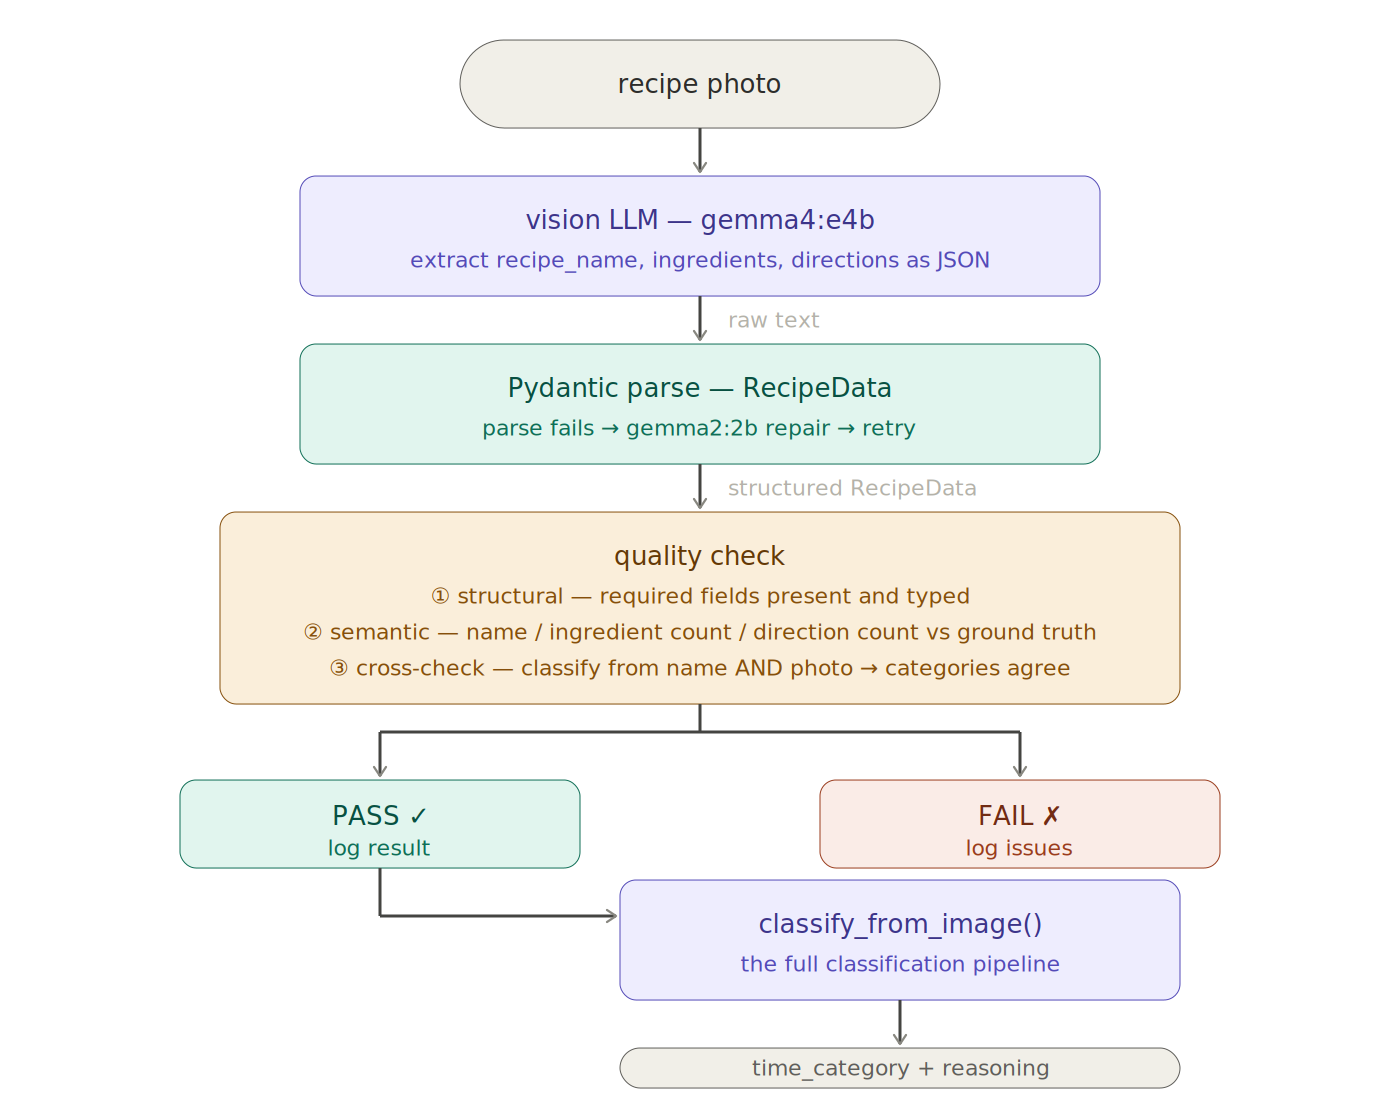

---
### Connect to Module 6 RAG

Now add the retrieval layers from module 6: infer skill level from user history and retrieve technique context. Same functions as module 6 -- unchanged.

**What the next cell rebuilds, and why:**

ChromaDB collections live in-process -- they don't survive across notebook sessions. The cell below recreates two collections under fresh names (`user_profiles_w7` and `techniques_w7`) so this notebook is self-contained: you can run it without first running the module 6 notebook in the same kernel.

- **`user_profiles_w7`** -- the same three users (Alice, Bob, Carol) and the same `infer_skill()` function from module 6. The retrieval logic is identical; only the collection name changes to keep the two notebooks isolated.
- **`techniques_w7`** -- populated from `data/technique_chunks_enriched.jsonl`, the cache produced by module 6's enrichment cell. If that file is missing the cell prints a warning and continues with technique retrieval disabled -- the personalized response degrades gracefully to skill-only rather than crashing.

**The point of this cell is to wire up the infrastructure that Cell 5 will use.** When you adapt this to your own domain, bring whatever retrieval setup your project already has and feed the photo-extracted JSON into it the same way you would feed typed input.

In [16]:
from pydantic import BaseModel
from typing import Literal
import requests
import chromadb


SYSTEM_PROMPT = """You are a cooking expert estimating how long a recipe will take for a specific cook.
Categories: A=≤30 min, B=30–60 min, C=>60 min.
Consider the cook's skill level when estimating time."""

class RecipeClassification(BaseModel):
    time_category: Literal["A", "B", "C"]
    reasoning: str


EMBED_MODEL = "nomic-embed-text"


def ollama_embed(texts: list[str], model: str = EMBED_MODEL, url: str = "http://localhost:11434") -> list[list[float]]:
    response = requests.post(
        f"{url}/api/embed",
        json={"model": model, "input": texts}
    )
    response.raise_for_status()
    return response.json()["embeddings"]


chroma_client = chromadb.Client()
user_collection = chroma_client.get_or_create_collection(
    name="user_profiles_w7", embedding_function=None # intentional
)

In [17]:
user_profiles = [
    {
        "user_id": "alice",
        "history": "scrambled eggs (5 times), pasta (3 times), carbonara (2 attempts — scrambled eggs both times), grilled cheese (4 times)",
        "inferred_skill": "intermediate-leaning-beginner",
        "skill_notes": "Comfortable with basic heat control; struggles with off-heat technique steps.",
    },
    {
        "user_id": "bob",
        "history": "croissants (1 attempt), beef wellington (1 time), hollandaise (3 times), homemade pasta (5 times)",
        "inferred_skill": "advanced",
        "skill_notes": "Comfortable with lamination, emulsification, and precision technique.",
    },
    {
        "user_id": "carol",
        "history": "taco bake (4 times), quesadillas (6 times), stir fry (2 times), pasta bake (3 times)",
        "inferred_skill": "confident-beginner",
        "skill_notes": "High confidence with oven and stovetop basics; no technique-heavy attempts.",
    },
]

embeddings = ollama_embed([p["history"] for p in user_profiles])

for p, embedding in zip(user_profiles, embeddings):
    user_collection.upsert(
        ids=[p["user_id"]],
        documents=[p["history"]],
        embeddings=[embedding],
        metadatas=[{"inferred_skill": p["inferred_skill"], "skill_notes": p["skill_notes"]}],
    )

In [18]:
from pathlib import Path

technique_collection = chroma_client.get_or_create_collection(
    name="techniques_w7",
    embedding_function=None
)

enriched_path = Path("data/technique_chunks_enriched.jsonl")
if enriched_path.exists():
    import json as _json
    enriched = [_json.loads(l) for l in enriched_path.read_text().splitlines() if l.strip()]
    embeddings = ollama_embed([c["text"] for c in enriched])
    technique_collection.upsert(
        ids=[c["technique"] for c in enriched],
        documents=[c["text"] for c in enriched],
        embeddings=embeddings,
        metadatas=[{"technique": c["technique"], "difficulty": c["difficulty"],
                    "beginner_failure_point": c["beginner_failure_point"]} for c in enriched],
    )
    print(f"Loaded {technique_collection.count()} technique chunks from week 6 cache.")
else:
    print("Week 6 technique cache not found — run week 6 notebook first to generate it.")
    print("Technique retrieval will be skipped in the personalised response.")


def infer_skill(user_history: str) -> dict:
    embedding = ollama_embed([user_history])[0]
    results = user_collection.query(query_embeddings=[embedding], n_results=1)
    return {
        "inferred_skill": results["metadatas"][0][0]["inferred_skill"],
        "skill_notes":    results["metadatas"][0][0]["skill_notes"],
    }


def retrieve_technique(recipe_name: str, directions: list) -> dict | None:
    if technique_collection.count() == 0:
        return None
    query = f"{recipe_name}: {' '.join(directions[:3])}"
    embedding = ollama_embed([query])[0]
    results = technique_collection.query(query_embeddings=[embedding], n_results=1)
    meta = results["metadatas"][0][0]
    return {
        "technique":              meta["technique"],
        "difficulty":             meta["difficulty"],
        "beginner_failure_point": meta["beginner_failure_point"],
        "text":                   results["documents"][0][0][:300],
    }

Loaded 17 technique chunks from week 6 cache.


---
### The Full Pipeline

One function. One photo. Six weeks of pipeline.

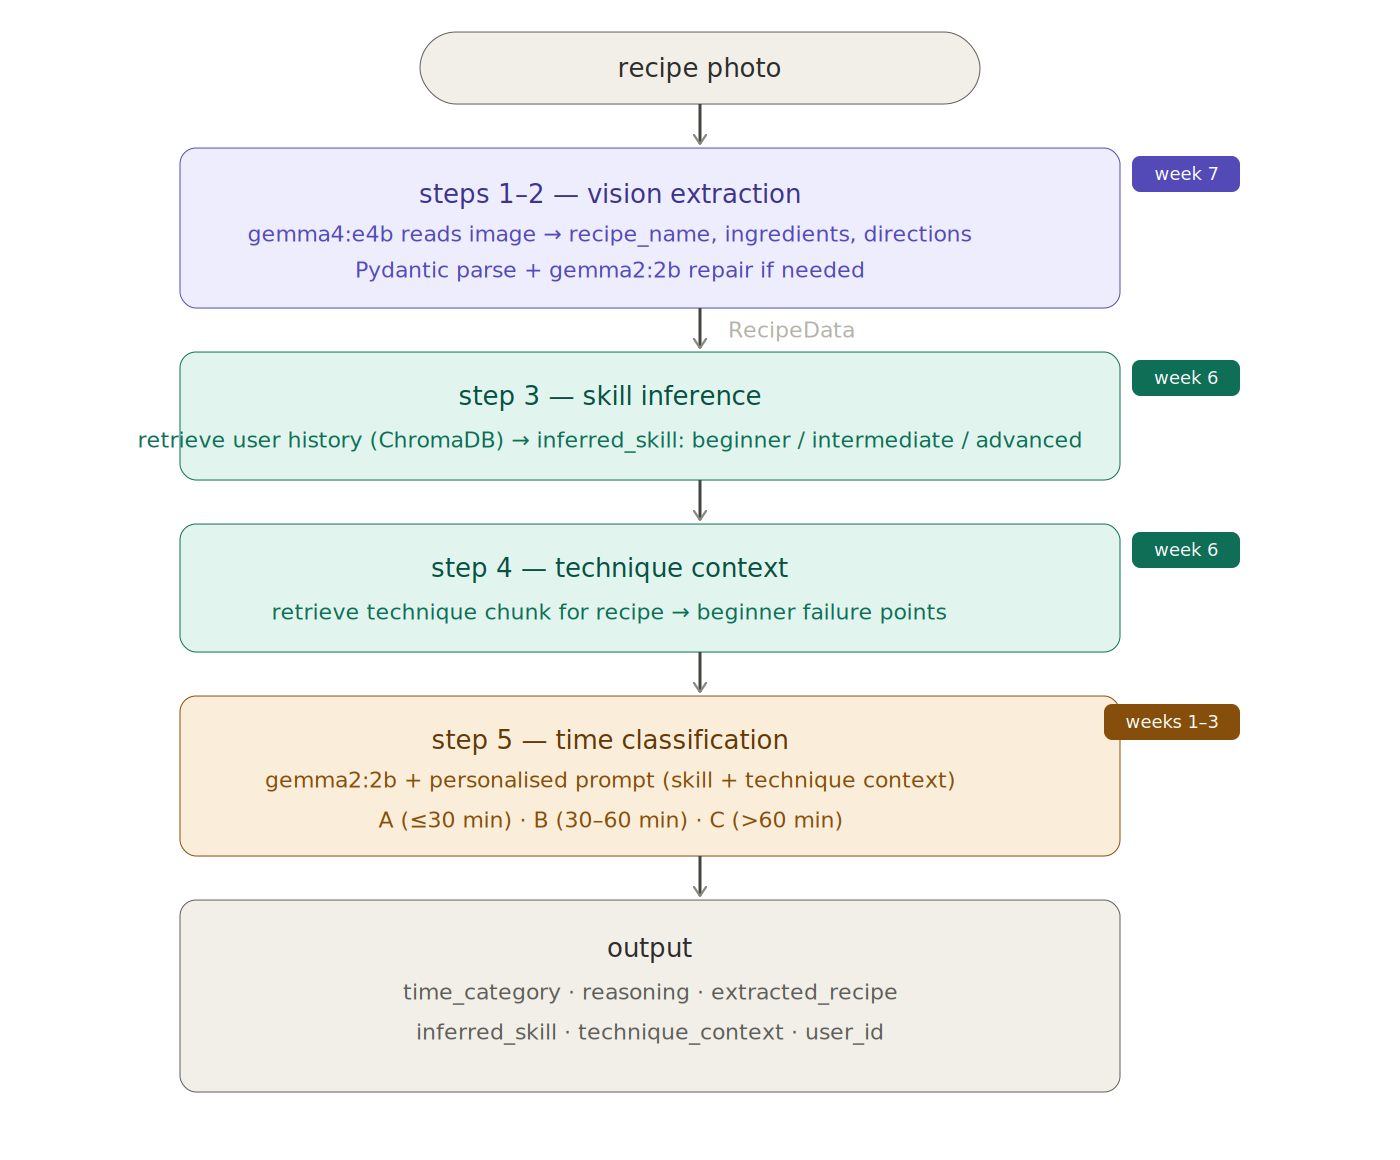

In [20]:
def classify_from_image(image_path: str, user_id: str) -> dict:
    """Run the complete week 1–7 pipeline on a recipe photo.

    Steps:
      1. Vision extraction  — gemma4:e4b reads the image
      2. Parse + correct    — JSON validation with gemma2:2b fallback
      3. Skill inference    — week 6 user profile retrieval
      4. Technique context  — week 6 technique chunk retrieval
      5. Classification     — gemma2:2b with personalised context

    Returns a dict with all intermediate results for inspection.
    """
    # Step 1–2: vision extraction
    recipe = extract_recipe(image_path)
    if recipe is None:
        return {"error": "Extraction failed — check raw output above"}

    # Step 3: skill inference from user history
    user_history_map = {p["user_id"]: p["history"] for p in user_profiles}
    history = user_history_map.get(user_id, f"user_id '{user_id}' not found")
    skill   = infer_skill(history)

    # Step 4: technique context
    technique = retrieve_technique(recipe["recipe_name"], recipe["directions"])

    # Step 5: personalised classification
    user_content = (
        f"Recipe: {recipe['recipe_name']}\n"
        f"Cook's profile: {skill['inferred_skill']} — {skill['skill_notes']}\n"
    )
    if technique:
        user_content += (
            f"Relevant technique — {technique['technique']} ({technique['difficulty']}):\n"
            f"  Common beginner mistake: {technique['beginner_failure_point']}\n"
        )
    user_content += "\nClassify the recipe time for this specific cook."

    response = ollama.chat(
        model=TEXT_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_content},
        ],
        format=RecipeClassification.model_json_schema(),
        options={"temperature": 0},
    )
    classification = json.loads(response.message.content)

    return {
        "image":              image_path,
        "extracted_recipe":   recipe["recipe_name"],
        "user_id":            user_id,
        "inferred_skill":     skill["inferred_skill"],
        "technique_context":  technique["technique"] if technique else None,
        "time_category":      classification["time_category"],
        "reasoning":          classification["reasoning"],
    }


# Same photo, two different users — different results
print("=" * 60)
for user_id in ["alice", "bob"]:
    result = classify_from_image(CARBONARA_IMAGE, user_id)
    print(f"User:            {result['user_id']} ({result['inferred_skill']})")
    print(f"Recipe (photo):  {result['extracted_recipe']}")
    print(f"Classification:  {result['time_category']}")
    print(f"Reasoning:       {result['reasoning'][:1200]}...")
    print("-" * 60)

User:            alice (intermediate-leaning-beginner)
Recipe (photo):  Pasta Carbonara
Classification:  B
Reasoning:       While pasta carbonara can be a delicious and relatively simple dish, it does involve some key steps that require attention to detail. The intermediate-leaning-beginner cook will likely struggle with the off-heat technique of cooking the sauce (which is crucial for achieving the creamy texture). This means they might need more time than a true beginner to get it right.  However, the recipe itself isn't overly complex and can be completed within 45 minutes to an hour....
------------------------------------------------------------
User:            bob (advanced)
Recipe (photo):  Pasta Carbonara
Classification:  B
Reasoning:       While pasta carbonara can be a relatively quick dish to make, the advanced cook will likely take some extra care with the technique and ingredients. This means they'll need to pay attention to the timing of the sauce and the cooking of the 

---
## Audio Transformers: The Same Architecture, A Different Modality

The pipeline we built this week uses vision as a second entry point. But the transformer architecture isn't limited to images. Here's how the same ideas apply to audio — and why that matters for your own domain.

### The Audio Transformer Encoder

> **The problem in one sentence:** 30 seconds of audio = 480,000 numbers. A transformer can't attend over a sequence that long.

#### Step 1 — Why We Can't Use Raw Audio Directly

Transformers use self-attention, which scales quadratically with sequence length. A 480,000-token sequence would need ~230 billion attention operations per layer. The fix is to compress the audio into a much shorter representation before the transformer ever sees it.

#### Step 2 — The Spectrogram Pipeline

The diagram below shows the full path from raw audio to transformer input, the two main approaches to audio encoding, and the two transformer architectures used downstream.



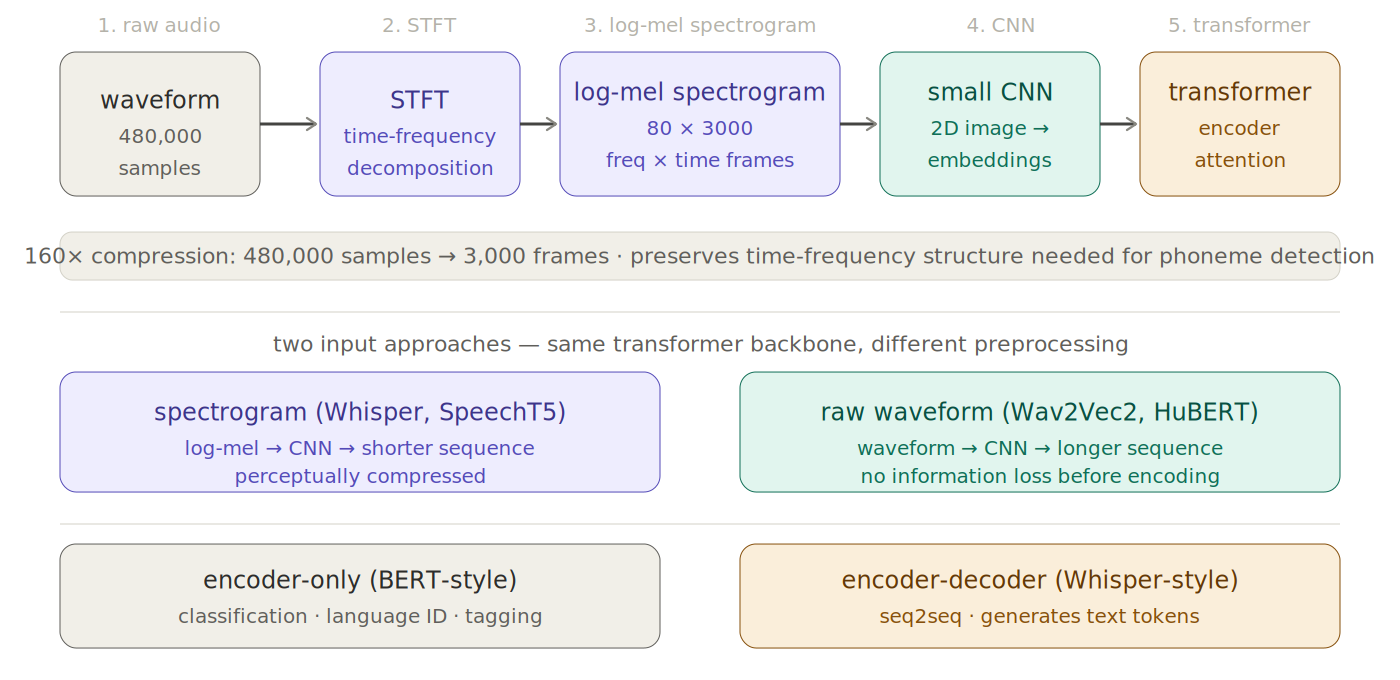



The key numbers to hold onto: **80 mel bins × 3,000 time frames** after STFT, then a small CNN compresses that 2D image into an embedding sequence the transformer can attend over. That's a **160× compression** — from 480,000 samples to 3,000 frames — while keeping the time-frequency structure the model needs to tell phonemes apart.

#### Step 3 — Two Ways to Feed Audio into a Transformer

Both approaches put a small CNN in front of the transformer. The CNN's job is the same in both cases: convert whatever the input format is into a fixed-size embedding sequence. The transformer backbone is identical — only the preprocessing changes.

| | Spectrogram | Raw waveform |
|---|---|---|
| **Models** | Whisper, SpeechT5 | Wav2Vec2, HuBERT |
| **CNN input** | 80 × 3,000 log-mel image | Raw samples (25 ms windows) |
| **Sequence length** | Shorter | Longer |
| **Trade-off** | Perceptually compressed | No information loss before encoding |

#### Step 4 — Encoder-Only vs Encoder-Decoder

Once you have the embedding sequence, you have two architectural choices depending on the task:

- **Encoder-only** (BERT-style) — reads the full sequence and produces contextual embeddings. Used for classification tasks: spoken language ID, emotion detection, audio tagging.
- **Encoder-decoder** (Whisper-style) — encoder reads the spectrogram, decoder generates text tokens one at a time. This is the same seq2seq pattern as machine translation, just with audio as the source language.

#### What This Means for Your Pipeline

Whisper outputs plain text. That text is identical in format to a typed recipe name — it slots directly into the extraction and classification pipeline without any changes. Voice input is just another entry point, the same way a photo is.

*The following section is conceptual — no hands-on code is provided. Audio integration follows the same modality-as-encoder pattern you just built for vision.*

If your domain involves voice (customer support calls, voice-controlled interfaces, meeting transcripts), the integration point is always: **Whisper → text → existing pipeline**.


> **Further reading:** [HuggingFace Audio Course — Chapter 3: Transformer Architectures for Audio](https://huggingface.co/learn/audio-course/chapter3/introduction) — covers the spectrogram pipeline, CTC vs seq2seq decoding, and how Wav2Vec2 and Whisper differ architecturally.

---

### Key Takeaways

- **Transformers are modality-agnostic.** The model doesn't care whether tokens represent words, image patches, or audio frames — as long as each is a fixed-size vector, the same attention mechanism applies. Multimodality is the art of building those vectors consistently.
- **Every modality follows the same pattern.** Modality-specific encoder → linear projector → token sequence that the language model can attend to. Swap the encoder; the rest of the pipeline stays the same.
- **Multimodal training happens in stages.** Vision encoder pre-training (learn visual structure), vision-language alignment (pull embeddings into a shared space via contrastive loss), then multimodal instruction fine-tuning (teach the model to generate grounded responses). The quality of Stage 3 data determines the model's specialization.
- **The projector is the learnable bridge.** It's a thin linear layer that maps between the vision encoder's embedding space and the language model's token space. You don't need to retrain either encoder — just the connector. Recent work shows this can be made 64× more data-efficient by sharing projector weights across modalities.
- **Vision adds a new entry point, not a new pipeline.** The downstream classifier, RAG layers, and structured output format from weeks 1–6 required zero changes. The vision step produces text; everything downstream consumes text. This composability is by design.
- **Model choice matters for your data distribution.** Gemma 4 (`e4b`) works well on recipe cards because its PaliGemma lineage fine-tuned it on documents and OCR tasks — not just natural photos. For your own domain, match the model's training distribution to your input type.
- **Audio is vision in disguise — but the architecture choice matters.** A mel spectrogram is a 2D image; a spectrogram-based encoder (Whisper) compresses 30 s of audio from 480,000 samples to 3,000 frames before the transformer sees anything. For raw-waveform models (Wav2Vec2, HuBERT), a CNN feature encoder does the compression instead. Either way, the transformer backbone is unchanged.

---

**Your assignment:**

1. Identify one visual input in your domain — a document, photo, form, or screenshot — that your pipeline currently requires users to type out
2. Build `extract_from_image(image_path)` for your domain: vision extraction → parse → correct
3. Connect it to your existing pipeline — nothing downstream should need to change
4. Evaluate: does the full pipeline produce the same quality output from a photo as it does from typed input?

To start your assignment, run in the Claude Code terminal:
```
Use assignment-partner skill to help me with this week's work.
```